# MDS dataset benchmarks

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import polars as pl
import mrmr
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData
import networkx as nx
from torch_geometric.utils import to_networkx
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, to_hetero, RGATConv, HeteroConv, Linear
from sklearn.manifold import TSNE
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader
from torchvision import transforms
import torch_geometric.transforms as T
import torch_geometric

from baseline_evals import knn_eval, svm_eval, xgboost_eval, feature_selection
from bipartite_gnn.preprocessing import get_gene_gene_interactions

In [92]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [3]:
# loading data
RNA = pl.read_csv("MDS_data/200625_allRNA_fromRNAseq_annot_hg38.tsv", separator="\t") # mix of different RNA types
circRNA = pl.read_csv("MDS_data/200625_circRNA_fromRNAseq_annot_hg19.tsv", separator="\t",  null_values=["NA"]) # circRNA
piRNA = pl.read_excel("MDS_data/piRNA_counts.xlsx", engine="xlsx2csv") # piRNA
miRNA = pl.read_excel("MDS_data/final_all_samples_miRNA_seq.xlsx", engine="xlsx2csv") # miRNA
sampleSheet = pl.read_excel("MDS_data/sample sheet for CVUT.xlsx", engine="xlsx2csv") # annotations

In [29]:
piRNA

piRNA,V1565_S17-UMIs,N58_S10-UMIs,V1874_S15-UMIs,V777_S8-UMIs,N80_S20-UMIs,V1788_S3-UMIs,N65_S19-UMIs,V2368_S6-UMIs,N81_S21-UMIs,N59_S18-UMIs,V2286_S2-UMIs,V406_S7-UMIs,V100_S12-UMIs,N82_S1-UMIs,V2133_S13-UMIs,V574_S16-UMIs,V2115_S9-UMIs,V1921_S11-UMIs,V714_S4-UMIs,V637_S14-UMIs,V1742_S5-UMIs,V1744_S2-UMIs,V2248_S3-UMIs,V1428_S4-UMIs,V18_S5-UMIs,V1857_S2-UMIs,V839_S13-UMIs,V912_S21-UMIs,V1048_S9-UMIs,V911_S10-UMIs,V940_S13-UMIs,V681_S21-UMIs,V708_S24-UMIs,N60_S12-UMIs,N70_S11-UMIs,V148_S12-UMIs,…,V1441_S29-UMIs,V1699_S1-UMIs,V1297_S1-UMIs,V1321_S15-UMIs,V1505_S30-UMIs,V1249_S18-UMIs,V1456_S8-UMIs,V1426_S26-UMIs,V1394_S27-UMIs,V1592_S15-UMIs,V1528_S14-UMIs,V1591_S22-UMIs,V833_S6-UMIs,V1708_S27-UMIs,V1800_S16-UMIs,V1776_S23-UMIs,V1823_S11-UMIs,V1775_S15-UMIs,V1834_S3-UMIs,V2378_S19-UMIs,V2414_S10-UMIs,V1860_S4-UMIs,V1884_S28-UMIs,V1920_S7-UMIs,V2322_S18-UMIs,V2311_S18-UMIs,V2291_S17-UMIs,V1957_S6-UMIs,V2092_S17-UMIs,V2284_S16-UMIs,V2278_S20-UMIs,V2110_S7-UMIs,V2179_S9-UMIs,V2147_S8-UMIs,V2224_S19-UMIs,V2089_S1-UMIs,V788_S2-UMIs
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""hsa_piR_006779…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_007653…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_009540…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000302…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000390…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hsa_piR_020814…",315,274,230,160,333,154,116,192,213,244,83,147,332,275,94,50,239,168,515,14,122,162,188,111,309,573,18,18,50,59,45,98,70,133,203,138,…,177,108,225,170,193,210,79,42,418,327,144,70,209,246,319,128,88,160,214,139,183,87,94,127,212,78,136,187,67,154,203,222,139,273,161,175,43
"""hsa_piR_020815…",316,458,493,422,279,266,140,417,243,395,220,74,361,450,77,120,715,170,210,12,289,688,336,203,604,137,104,193,270,276,265,202,410,132,225,291,…,340,201,157,1068,389,405,177,89,1005,578,329,314,574,551,458,187,117,421,669,646,183,250,170,131,635,248,170,864,126,293,571,231,224,281,574,183,120
"""hsa_piR_020829…",2732,1064,1346,610,1598,894,848,528,1525,1060,810,565,824,1131,380,1242,833,1493,2428,146,901,1991,378,714,3829,766,226,175,544,380,632,547,312,589,472,1735,…,65,1050,383,193,1198,264,610,112,492,475,1173,1241,330,385,292,375,506,325,687,330,1212,777,665,138,1620,357,621,874,573,661,1069,1170,784,749,1192,921,391


In [31]:
annot = pl.read_csv("MDS_data_preprocessed/annotations.csv")

In [32]:
annot

SAMPLE_NAME,1 disease,2 risk,3 mutations (SF3B1only_wt),sample_ids
str,i64,i64,i64,str
"""V1884_S17""",2,2,0,"""V1884"""
"""N58_S18""",1,0,0,"""N58"""
"""V630_S11""",2,1,1,"""V630"""
"""N60_S15""",1,0,0,"""N60"""
"""V1297_S10""",2,2,0,"""V1297"""
…,…,…,…,…
"""V1048_S12""",2,1,0,"""V1048"""
"""V806_S1""",2,2,2,"""V806"""
"""V513_S16""",2,2,1,"""V513"""


In [26]:
pirnax = piRNA[:, 1:].to_numpy().T

In [28]:
pirnax.shape

(104, 556)

In [94]:
RNA

CHR,START,END,GENE_ID,GENE_TYPE,GENE_NAME,N54_S14,N58_S18,N60_S15,N70_S16,N82_S1,N83_S3,N84_S4,N85_S19,N86_S13,N87_S20,NV1428_S3,NV911_S19,NV912_S20,V1048_S12,V108_S5,V1090_S8,V1249_S13,V125_S5,V1279_S21,V1297_S10,V1321_S4,V1337_S3,V1394_S4,V1422_S6,V1426_S9,V1441_S2,V1456_S13,V148_S10,V1505_S10,V1528_S12,V1554_S11,…,V1921_S15,V2089_S9,V2092_S3,V2110_S16,V2133_S17,V221_S19,V2241_S15,V344_S16,V359_S3,V406_S18,V456_S4,V513_S16,V538_S12,V553_S11,V574_S9,V624_S15,V630_S11,V637_S21,V655_S18,V67_S6,V681_S10,V708_S17,V712_S22,V714_S19,V716_S1,V777_S20,V788_S11,V795_S8,V806_S1,V833_S12,V839_S17,V853_S7,V883_S4,V888_S2,V940_S8,V956_S6,V957_S2
str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""chr3""",168903366,168921996,"""ENSG0000024226…","""lincRNA""","""RP11-368I23.2""",89,55,79,66,86,268,90,84,122,65,26,20,14,0,314,174,104,114,114,12,267,18,17,69,0,28,49,58,31,25,0,…,82,0,25,18,15,69,69,0,73,9,481,59,83,3,28,4,81,7,4,254,38,6,110,20,266,179,17,80,71,207,42,126,176,48,31,44,0
"""chr12""",123470054,123533718,"""ENSG0000018802…","""protein_coding…","""RILPL1""",407,235,244,266,89,232,198,246,134,279,131,133,114,404,60,207,196,172,146,256,393,195,110,106,463,128,239,203,223,153,65,…,200,120,362,315,93,170,376,120,715,180,314,263,128,426,352,164,538,44,131,432,262,98,65,92,355,167,283,122,458,439,139,260,273,474,364,176,69
"""chr18""",46756487,46764408,"""ENSG0000027011…","""processed_tran…","""RP11-742D12.2""",6,9,70,0,10,0,9,7,0,7,0,0,3,0,4,5,7,2,1,11,4,4,0,0,8,0,0,4,0,4,0,…,0,3,36,20,86,13,15,4,4,6,0,2,4,64,4,0,4,0,30,0,3,0,14,43,52,0,24,6,0,20,0,1,6,18,10,0,8
"""chr19""",40778216,40796938,"""ENSG0000016757…","""protein_coding…","""RAB4B""",951,951,856,905,749,865,1441,682,851,681,849,555,454,764,1080,812,1214,710,1111,613,1526,1348,1390,765,1665,527,1259,1026,1317,1183,412,…,914,1798,937,812,304,636,1165,1137,1514,1024,920,989,948,2094,1350,1989,1261,460,685,1374,778,831,786,1370,1304,882,3043,1605,801,1118,907,1815,887,1130,813,0,1242
"""chr19""",23399233,23416075,"""ENSG0000026941…","""lincRNA""","""CTB-175P5.4""",34,84,50,66,51,31,41,19,30,40,32,10,45,12,0,28,7,40,36,14,21,16,3,106,5,0,11,147,86,112,16,…,20,212,34,9,70,64,40,0,28,29,7,97,0,0,256,23,27,9,0,21,0,17,16,80,29,32,82,34,28,18,0,23,0,77,36,0,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr8""",17681578,17681657,"""ENSG0000026552…","""miRNA""","""MIR548V""",0,0,0,1,2,5,14,0,4,0,0,0,0,0,0,1,0,0,0,0,2,4,0,0,0,0,0,2,0,0,0,…,0,0,0,1,3,2,0,0,2,0,1,0,0,0,0,0,0,0,3,1,0,0,0,0,5,1,1,0,0,4,0,0,0,0,0,0,2
"""chr19""",55229780,55258995,"""ENSG0000010506…","""protein_coding…","""PPP6R1""",22845,28193,26489,21006,17065,22682,26769,18729,20738,22708,18446,18690,18843,24906,15464,18758,21505,28065,21519,26893,24247,22835,31129,19041,93501,24492,25224,19994,24718,21241,8544,…,17448,34875,15198,22322,4353,14988,20336,32244,31834,21384,15798,18774,17235,29815,30757,27047,23945,7123,14442,23880,29027,27304,13041,20407,23342,15997,46899,40751,27759,24271,16824,33950,23426,30607,25504,0,25170
"""chr11""",123902167,123909229,"""ENSG0000018151…","""protein_coding…","""OR8D4""",0,0,0,0,0,0,0,4,0,7,0,3,0,0,43,0,0,3,4,0,3,0,0,36,0,3,0,0,0,0,4,…,3,0,8,0,29,4,10,0,0,7,0,0,4,5,3,0,0,0,39,0,3,0,4,3,0,7,8,6,0,6,0,0,0,3,0,8,4


In [4]:
piRNA

piRNA,V1565_S17-UMIs,N58_S10-UMIs,V1874_S15-UMIs,V777_S8-UMIs,N80_S20-UMIs,V1788_S3-UMIs,N65_S19-UMIs,V2368_S6-UMIs,N81_S21-UMIs,N59_S18-UMIs,V2286_S2-UMIs,V406_S7-UMIs,V100_S12-UMIs,N82_S1-UMIs,V2133_S13-UMIs,V574_S16-UMIs,V2115_S9-UMIs,V1921_S11-UMIs,V714_S4-UMIs,V637_S14-UMIs,V1742_S5-UMIs,V1744_S2-UMIs,V2248_S3-UMIs,V1428_S4-UMIs,V18_S5-UMIs,V1857_S2-UMIs,V839_S13-UMIs,V912_S21-UMIs,V1048_S9-UMIs,V911_S10-UMIs,V940_S13-UMIs,V681_S21-UMIs,V708_S24-UMIs,N60_S12-UMIs,N70_S11-UMIs,V148_S12-UMIs,…,V1441_S29-UMIs,V1699_S1-UMIs,V1297_S1-UMIs,V1321_S15-UMIs,V1505_S30-UMIs,V1249_S18-UMIs,V1456_S8-UMIs,V1426_S26-UMIs,V1394_S27-UMIs,V1592_S15-UMIs,V1528_S14-UMIs,V1591_S22-UMIs,V833_S6-UMIs,V1708_S27-UMIs,V1800_S16-UMIs,V1776_S23-UMIs,V1823_S11-UMIs,V1775_S15-UMIs,V1834_S3-UMIs,V2378_S19-UMIs,V2414_S10-UMIs,V1860_S4-UMIs,V1884_S28-UMIs,V1920_S7-UMIs,V2322_S18-UMIs,V2311_S18-UMIs,V2291_S17-UMIs,V1957_S6-UMIs,V2092_S17-UMIs,V2284_S16-UMIs,V2278_S20-UMIs,V2110_S7-UMIs,V2179_S9-UMIs,V2147_S8-UMIs,V2224_S19-UMIs,V2089_S1-UMIs,V788_S2-UMIs
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""hsa_piR_006779…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_007653…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_009540…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000302…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000390…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hsa_piR_020814…",315,274,230,160,333,154,116,192,213,244,83,147,332,275,94,50,239,168,515,14,122,162,188,111,309,573,18,18,50,59,45,98,70,133,203,138,…,177,108,225,170,193,210,79,42,418,327,144,70,209,246,319,128,88,160,214,139,183,87,94,127,212,78,136,187,67,154,203,222,139,273,161,175,43
"""hsa_piR_020815…",316,458,493,422,279,266,140,417,243,395,220,74,361,450,77,120,715,170,210,12,289,688,336,203,604,137,104,193,270,276,265,202,410,132,225,291,…,340,201,157,1068,389,405,177,89,1005,578,329,314,574,551,458,187,117,421,669,646,183,250,170,131,635,248,170,864,126,293,571,231,224,281,574,183,120
"""hsa_piR_020829…",2732,1064,1346,610,1598,894,848,528,1525,1060,810,565,824,1131,380,1242,833,1493,2428,146,901,1991,378,714,3829,766,226,175,544,380,632,547,312,589,472,1735,…,65,1050,383,193,1198,264,610,112,492,475,1173,1241,330,385,292,375,506,325,687,330,1212,777,665,138,1620,357,621,874,573,661,1069,1170,784,749,1192,921,391


In [5]:
common_names = list(set(RNA.columns) & set(sampleSheet['SAMPLE_NAME']))
common_names.sort()

In [6]:
rna_genes = RNA['GENE_NAME']

In [7]:
RNA = RNA.select(common_names)

In [8]:
RNA

N54_S14,N58_S18,N60_S15,N70_S16,N82_S1,N83_S3,N84_S4,N85_S19,N86_S13,N87_S20,NV1428_S3,NV911_S19,NV912_S20,V1048_S12,V108_S5,V1090_S8,V125_S5,V1279_S21,V1297_S10,V1321_S4,V1337_S3,V1394_S4,V1422_S6,V1441_S2,V1456_S13,V148_S10,V1505_S10,V1528_S12,V1565_S13,V1591_S14,V1592_S5,V1699_S2,V1708_S22,V1742_S5,V1776_S9,V1788_S2,V1800_S1,V1823_S7,V1834_S7,V1857_S8,V1860_S18,V1874_S1,V1884_S17,V18_S20,V1920_S14,V1921_S15,V2089_S9,V2092_S3,V2110_S16,V221_S19,V2241_S15,V344_S16,V359_S3,V406_S18,V456_S4,V513_S16,V538_S12,V553_S11,V574_S9,V624_S15,V630_S11,V637_S21,V655_S18,V67_S6,V712_S22,V714_S19,V716_S1,V777_S20,V806_S1,V839_S17,V883_S4,V888_S2,V940_S8,V956_S6
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
89,55,79,66,86,268,90,84,122,65,26,20,14,0,314,174,114,114,12,267,18,17,69,28,49,58,31,25,35,13,57,67,95,22,40,0,39,37,70,39,106,106,20,13,576,82,0,25,18,69,69,0,73,9,481,59,83,3,28,4,81,7,4,254,110,20,266,179,71,42,176,48,31,44
407,235,244,266,89,232,198,246,134,279,131,133,114,404,60,207,172,146,256,393,195,110,106,128,239,203,223,153,384,226,210,345,139,698,62,184,464,570,301,276,373,114,187,233,649,200,120,362,315,170,376,120,715,180,314,263,128,426,352,164,538,44,131,432,65,92,355,167,458,139,273,474,364,176
6,9,70,0,10,0,9,7,0,7,0,0,3,0,4,5,2,1,11,4,4,0,0,0,0,4,0,4,4,3,0,26,4,11,7,0,0,0,92,151,10,0,12,0,17,0,3,36,20,13,15,4,4,6,0,2,4,64,4,0,4,0,30,0,14,43,52,0,0,0,6,18,10,0
951,951,856,905,749,865,1441,682,851,681,849,555,454,764,1080,812,710,1111,613,1526,1348,1390,765,527,1259,1026,1317,1183,1682,1177,753,2000,1195,1420,860,1033,1683,792,1072,434,1238,2095,1296,860,943,914,1798,937,812,636,1165,1137,1514,1024,920,989,948,2094,1350,1989,1261,460,685,1374,786,1370,1304,882,801,907,887,1130,813,0
34,84,50,66,51,31,41,19,30,40,32,10,45,12,0,28,40,36,14,21,16,3,106,0,11,147,86,112,769,35,110,93,52,65,31,18,0,48,30,77,12,69,10,613,6,20,212,34,9,64,40,0,28,29,7,97,0,0,256,23,27,9,0,21,16,80,29,32,28,0,0,77,36,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,1,2,5,14,0,4,0,0,0,0,0,0,1,0,0,0,2,4,0,0,0,0,2,0,0,0,0,6,3,0,3,0,0,2,0,4,6,0,0,0,0,0,0,0,0,1,2,0,0,2,0,1,0,0,0,0,0,0,0,3,1,0,0,5,1,0,0,0,0,0,0
22845,28193,26489,21006,17065,22682,26769,18729,20738,22708,18446,18690,18843,24906,15464,18758,28065,21519,26893,24247,22835,31129,19041,24492,25224,19994,24718,21241,43097,28033,17662,32556,20384,33745,16367,27921,49107,17279,11683,3737,18556,23251,24306,42835,16402,17448,34875,15198,22322,14988,20336,32244,31834,21384,15798,18774,17235,29815,30757,27047,23945,7123,14442,23880,13041,20407,23342,15997,27759,16824,23426,30607,25504,0
0,0,0,0,0,0,0,4,0,7,0,3,0,0,43,0,3,4,0,3,0,0,36,3,0,0,0,0,0,0,0,3,3,0,4,0,3,0,9,14,4,4,0,12,34,3,0,8,0,4,10,0,0,7,0,0,4,5,3,0,0,0,39,0,4,3,0,7,0,0,0,3,0,8


In [9]:
X = RNA.to_numpy().T
X = np.log2(X + 1)

In [10]:
X.shape

(74, 58216)

In [11]:
sampleSheet = sampleSheet.filter(pl.col('SAMPLE_NAME').is_in(common_names))

In [12]:
sampleSheet = sampleSheet.sort("SAMPLE_NAME")

In [13]:
sampleSheet

SAMPLE_NAME,GROUP,1 disease,2 risk,3 mutations (SF3B1only_wt),RUN,PLATFORM,N_UNIQ_MAP_READS,UNIQ_MAP
str,str,i64,i64,i64,str,str,i64,f64
"""N54_S14""","""CTR""",1,0,0,"""19_03_17""","""HiSeq""",70427795,90.56
"""N58_S18""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",68450889,89.41
"""N60_S15""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",78931939,87.3
"""N70_S16""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",80070799,87.48
"""N82_S1""","""CTR""",1,0,0,"""19_01_21""","""HiSeq""",59676688,86.17
…,…,…,…,…,…,…,…,…
"""V839_S17""","""EPI""",2,2,0,"""19_01_21""","""HiSeq""",63940521,90.54
"""V883_S4""","""SPL/EPI""",2,1,0,"""20_01_23""","""NovaSeq""",55889746,87.78
"""V888_S2""","""SPL""",2,1,2,"""19_08_12""","""NovaSeq""",88749877,88.0


In [23]:
y_d = sampleSheet['1 disease'].to_numpy()
y_r = sampleSheet['2 risk'].to_numpy()
y_m = sampleSheet['3 mutations (SF3B1only_wt)'].to_numpy()

# select the labels to use
y = y_r

samples_selected_mask = y != 0
samples_selected_mask

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False,  True,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True,  True,  True,  True,
        True,  True])

In [19]:
X[y_r != 0].shape, y_r[y_r != 0].shape

((53, 58216), (53,))

In [21]:
X[y_m != 0].shape, y_m[y_m != 0].shape

((26, 58216), (26,))

In [15]:
np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([0, 1]), array([13, 61])),
 (array([0, 1, 2]), array([21, 29, 24])),
 (array([0, 1, 2]), array([48, 13, 13])))

In [105]:
y = y_m

In [259]:
from baseline_evals.feature_selection import class_variational_selection


train_indices, test_indices = train_test_split(
    np.arange(X.shape[0]),
    test_size=0.2,
    stratify=y,
    random_state=45
)
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

select_mask, _ = class_variational_selection(X_train, y_train, 100)

X_train = X_train[:, select_mask]
X_test = X_test[:, select_mask]

std_scale = StandardScaler().fit(X_train)
X_train = std_scale.transform(X_train) 
X_test = std_scale.transform(X_test)

In [173]:
selected_genes = rna_genes.to_numpy()[select_mask]

In [174]:
selected_genes

array(['RHOC', 'MDN1', 'RP11-626P14.2', 'CTD-2128A3.2', 'TRIM6-TRIM34',
       'FABP7', 'RN7SKP34', 'RP11-380N8.4', 'RP11-62C7.2', 'AC009238.6',
       'FKBP8', 'MIR4498', 'GALNT12', 'EPDR1', 'RP11-28B23.1', 'OR7A18P',
       'AC009495.3', 'RNU6-874P', 'AC016747.3', 'ERAP1', 'RP4-555N2.3',
       'MATN2', 'COMMD7', 'ATP1A3', 'MIR7154', 'RP11-167P11.3',
       'RP11-39K24.4', 'B4GALT5', 'TULP1', 'RP11-169O17.6', 'AP001471.1',
       'OR10J5', 'RNF125', 'DONSON', 'RP11-588P7.1', 'IKZF2',
       'RP11-438J1.1', 'AC026271.5', 'KLHL30', 'SHF', 'CELF2', 'EXPH5',
       'RF00554', 'RP11-1293J14.1', 'AC078899.2', 'RP11-576N17.2',
       'APITD1-CORT', 'FUT5', 'CTD-2382E5.4', 'RP1-142O9.2', 'OMA1',
       'TP53TG3GP', 'VNN1', 'RP11-417C21.2', 'RNU6-642P', 'RP11-153K11.6',
       'MIR1237', 'RP5-1022P6.5', 'RP11-442J17.3', 'RP11-80B17.1',
       'RP11-56L13.1', 'CTD-2290C23.3', 'RP11-255E6.5', 'PLXDC1', 'SBK2',
       'RP11-674N23.4', 'RP3-414A15.11', 'RP5-1096D14.5', 'AES', 'EMX2OS',
       'HA

In [175]:
for i, gene in enumerate(selected_genes):
    selected_genes[i] = gene.split("-")[0]

In [176]:
selected_genes

array(['RHOC', 'MDN1', 'RP11', 'CTD', 'TRIM6', 'FABP7', 'RN7SKP34',
       'RP11', 'RP11', 'AC009238.6', 'FKBP8', 'MIR4498', 'GALNT12',
       'EPDR1', 'RP11', 'OR7A18P', 'AC009495.3', 'RNU6', 'AC016747.3',
       'ERAP1', 'RP4', 'MATN2', 'COMMD7', 'ATP1A3', 'MIR7154', 'RP11',
       'RP11', 'B4GALT5', 'TULP1', 'RP11', 'AP001471.1', 'OR10J5',
       'RNF125', 'DONSON', 'RP11', 'IKZF2', 'RP11', 'AC026271.5',
       'KLHL30', 'SHF', 'CELF2', 'EXPH5', 'RF00554', 'RP11', 'AC078899.2',
       'RP11', 'APITD1', 'FUT5', 'CTD', 'RP1', 'OMA1', 'TP53TG3GP',
       'VNN1', 'RP11', 'RNU6', 'RP11', 'MIR1237', 'RP5', 'RP11', 'RP11',
       'RP11', 'CTD', 'RP11', 'PLXDC1', 'SBK2', 'RP11', 'RP3', 'RP5',
       'AES', 'EMX2OS', 'HAS1', 'RNU6', 'EXOC7', 'MIR6875', 'CH17',
       'RN7SL97P', 'RP11', 'MLLT11', 'RP11', 'RP11', 'MIR23A', 'CRIPT',
       'CDKN2D', 'VMP1', 'MIR6742', 'RP11', 'MIR19B1', 'RP11', 'LPP',
       'SHISA9', 'RP11', 'AC131056.3', 'RP11', 'RP11', 'RP11', 'MTHFD1',
       'RP11', 'RP11

In [178]:
knn_eval.knn_eval(X, y, norm_features=True, n_evals=20, n_features=3000, test_size=0.1)

| KNN | 0.64 +/- 0.14 | 0.46 +/- 0.18 | 0.59 +/- 0.15 |
study.best_value=0.5933629564879566, study.best_params={'n_neighbors': 1}


In [30]:
svm_eval.svm_eval(X, y, norm_features=True, n_features_preselect=5000, n_features=500)

Trial 1 / 40
| SVM | 0.59 +/- 0.22 | 0.53 +/- 0.22 | 0.60 +/- 0.20 |
Trial 2 / 40
| SVM | 0.61 +/- 0.22 | 0.54 +/- 0.22 | 0.62 +/- 0.21 |
Trial 3 / 40
Trial 4 / 40
Trial 5 / 40
Trial 6 / 40
Trial 7 / 40
Trial 8 / 40
Trial 9 / 40
Trial 10 / 40
Trial 11 / 40
Trial 12 / 40
Trial 13 / 40
Trial 14 / 40
Trial 15 / 40
Trial 16 / 40
Trial 17 / 40
Trial 18 / 40
Trial 19 / 40
Trial 20 / 40
Trial 21 / 40
Trial 22 / 40
Trial 23 / 40
Trial 24 / 40
Trial 25 / 40
Trial 26 / 40
Trial 27 / 40
Trial 28 / 40
Trial 29 / 40
Trial 30 / 40
Trial 31 / 40
Trial 32 / 40
Trial 33 / 40
Trial 34 / 40
Trial 35 / 40
Trial 36 / 40
Trial 37 / 40
Trial 38 / 40
Trial 39 / 40
Trial 40 / 40
| LIN SVM | 0.61 +/- 0.22 | 0.54 +/- 0.22 | 0.62 +/- 0.21 |
study.best_value=0.6152426046176046, study.best_params={'C': 1.3825931350103358, 'class_weight': 'balanced'}


{'acc': 0.6071428571428571,
 'f1_macro': 0.5402501202501202,
 'f1_weighted': 0.6152426046176046,
 'acc_std': 0.21914141366632064,
 'f1_macro_std': 0.22443900923400648,
 'f1_weighted_std': 0.2060243926890167}

In [138]:
xgboost_eval.xgboost_eval(X, y, n_features=None)

0 / 50
ACC: [0.66666667 0.73333333 0.8        0.66666667 0.66666667]
F1M: [0.27777778 0.5        0.67874396 0.26666667 0.26666667]
F1W: [0.55555556 0.64444444 0.76859903 0.53333333 0.53333333]
| XGBoost | 0.71 +/- 0.05 | 0.40 +/- 0.17 | 0.61 +/- 0.09 |
1 / 50
ACC: [0.66666667 0.66666667 0.66666667 0.66666667 0.66666667]
F1M: [0.26666667 0.26666667 0.26666667 0.26666667 0.26666667]
F1W: [0.53333333 0.53333333 0.53333333 0.53333333 0.53333333]
2 / 50
ACC: [0.66666667 0.66666667 0.53333333 0.53333333 0.73333333]
F1M: [0.5745098  0.49494949 0.34444444 0.24242424 0.66666667]
F1W: [0.70235294 0.63434343 0.51111111 0.48484848 0.74666667]
| XGBoost | 0.63 +/- 0.08 | 0.46 +/- 0.15 | 0.62 +/- 0.10 |
3 / 50
ACC: [0.66666667 0.8        0.53333333 0.53333333 0.6       ]
F1M: [0.27777778 0.62318841 0.25396825 0.23188406 0.45555556]
F1W: [0.55555556 0.71304348 0.50793651 0.46376812 0.55555556]
4 / 50
ACC: [0.66666667 0.6        0.66666667 0.6        0.8       ]
F1M: [0.55396825 0.42063492 0.42753623 

In [23]:
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, X, y, transform=None):
    """
    This function initializes the MyDataset class.

    Args:
        X (np.ndarray): The features (data points).
        y (np.ndarray): The labels (target values).
        transform (torchvision.transforms, optional): A transform to apply to the data. Defaults to None.
    """
    self.X = X
    self.y = y
    self.transform = transform  # Optional transform

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    X_sample = self.X[idx]
    y_sample = self.y[idx]

    # Apply transform if provided
    if self.transform:
      X_sample = self.transform(X_sample)  # Convert to PyTorch tensor

    return X_sample, y_sample


X_train, X_test = torch.tensor(X_train), torch.tensor(X_test)
y_train, y_test = torch.tensor(y_train), torch.tensor(y_test)

# Convert data to torch.float32
X_train = X_train.float()
X_test = X_test.float()

# Create datasets with transforms (assuming your data is suitable for ToTensor)
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_test, y_test)
test_dataset = MyDataset(X_test, y_test)

batch_size = 32  # Adjust batch size based on your hardware and data size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [24]:
class MLP(torch.nn.Module):
    def __init__(self, input_sz, num_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(input_sz, hidden_channels)
        self.lin2 = Linear(hidden_channels, num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)  # Corrected this line
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.lin2(x)
        return x

class MLPTrainer(L.LightningModule):  # Fixed the import of LightningModule
    def __init__(self, net):  # Changed 'Net' to 'net'
        super().__init__()
        self.net = net  # Changed 'Net' to 'net'

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        val_loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        val_f1 = f1_score(y, y_pred.argmax(dim=1), average='weighted')  # Fixed the calculation of f1_score
        self.log('val_loss', val_loss)

        y_pred = y_pred.argmax(dim=1)
        
        accs = accuracy_score(y_test, y_pred)
        f1_macros = f1_score(y_test, y_pred, average="macro")
        f1_scores = f1_score(y_test, y_pred, average="weighted")

        # print(
        #     f"| MLP | {accs:.2f} | {f1_macros:.2f} | {f1_scores:.2f} |",
        # )
        
        # print('val_f1', val_f1)

    def test_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)

        y_pred = y_pred.argmax(dim=1)

        accs = accuracy_score(y_test, y_pred)
        f1_macros = f1_score(y_test, y_pred, average="macro")
        f1_scores = f1_score(y_test, y_pred, average="weighted")

        print(
            f"| MLP | {accs:.2f} | {f1_macros:.2f} | {f1_scores:.2f} |",
        )

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
        return {
            "optimizer": optimizer,
            "lr_scheduler_config": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            }
        }
# Assuming X_train, X_val, X_test, y_train, y_val, y_test, train_loader, test_loader are already defined

# Create model instance
model = MLP(
    input_sz=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_channels=32
)

# Create LightningModule instance
mlp = MLPTrainer(model)

# Create PyTorch Lightning Trainer
trainer = L.Trainer(
    max_epochs=40,
    log_every_n_steps=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min")],
)

# Train the model
trainer.fit(
    model=mlp,
    train_dataloaders=train_loader,  # Fixed the argument name
    val_dataloaders=val_loader  # Added validation data
)

# Test the model
trainer.test(
    model=mlp,
    dataloaders=test_loader  # Fixed the argument name
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:376: Found unsupported keys in the optimizer configuration: {'lr_scheduler_config'}

  | Name | Type | Params
------------------------------
0 | net  | MLP  | 3.3 K 
------------------------------


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=40` reached.


Testing: |                                                                                                    …

| MLP | 0.65 | 0.36 | 0.57 |


[{}]

In [240]:
def cosine_similarity_matrix(matrix):
    """
    given a matrix of (n_samples, n_features) compute the cosine similarities, between the samples
    """
    # Compute dot product between all pairs of vectors
    dot_products = np.dot(matrix, matrix.T)
    
    # Compute magnitudes of all vectors
    magnitudes = np.linalg.norm(matrix, axis=1)
    
    # Compute outer product of magnitudes to obtain matrix of magnitudes product
    magnitude_products = np.outer(magnitudes, magnitudes)
    
    # Compute cosine similarity matrix
    cosine_similarities = dot_products / magnitude_products
    
    return cosine_similarities

def keep_n_neighbours(A, n):
      rows, cols = A.shape
      for i in range(rows):
        # Find indices of the k highest elements
        bottom_k_indices = np.argsort(A[i])[:-n]
        # Set all other elements to zero
        A[i][bottom_k_indices] = 0
      return A
    

def dense_to_coo(adj_mat):
    """
    convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = np.where(adj_mat != 0)
    indices = np.vstack((indices[0], indices[1]))
    return torch.tensor(indices, dtype=torch.int64)
    
def dense_to_attributes(adj_mat):
    """
    return the flattened weight entries from the matrix
    for use as edge attributes
    """
    return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)
    

In [203]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels):
        super().__init__()
        # torch.manual_seed(1234567)
        self.conv1 = GCNConv(input_sz, hidden_channels, add_self_loops=True)
        self.conv2 = GCNConv(hidden_channels, n_classes, add_self_loops=True)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels, heads):
        super().__init__()
        # torch.manual_seed(123445567)
        self.conv1 = GATv2Conv(input_sz, hidden_channels, heads, dropout=0.2, add_self_loops=True)
        self.conv2 = GATv2Conv(hidden_channels * heads, n_classes, heads=1, concat=False, dropout=0.2, add_self_loops=True)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)
        x= self.conv2(x, edge_index)
        return x

In [115]:
X

array([[6.4918531 , 8.67242534, 2.80735492, ..., 0.        , 6.59991284,
        7.37503943],
       [5.80735492, 7.88264305, 3.32192809, ..., 0.        , 5.80735492,
        7.32192809],
       [6.32192809, 7.93663794, 6.14974712, ..., 0.        , 6.42626475,
        7.09803208],
       ...,
       [5.61470984, 8.8917837 , 4.24792751, ..., 2.        , 5.24792751,
        7.72109919],
       [5.        , 8.51175265, 3.45943162, ..., 0.        , 1.5849625 ,
        4.45943162],
       [5.4918531 , 7.46760555, 0.        , ..., 3.169925  , 0.        ,
        6.82017896]])

[[1.         0.98355867 0.98338107 ... 0.         0.         0.        ]
 [0.         1.         0.         ... 0.         0.         0.        ]
 [0.98338107 0.98305459 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]
(74, 58216)
torch.Size([2, 296])
num of isolated nodees 0


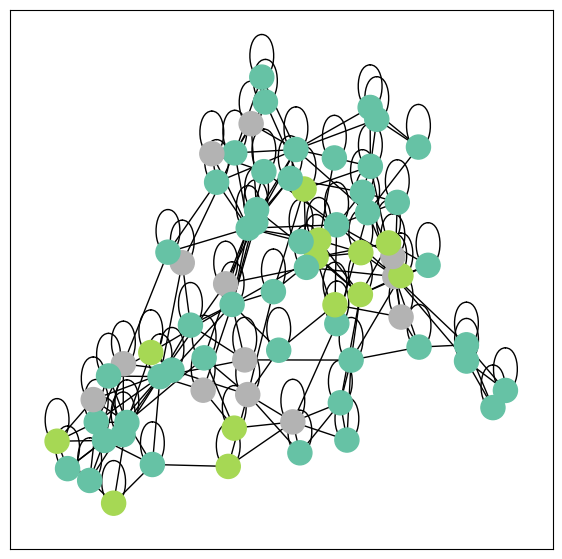

In [260]:
# build mogonet style GNN with
# a. thresholded cosine similarity

# transform features to (n_samples, n_features) tensor
Xs = X[:, select_mask]

# construct adjacency matrix
eps = 0.97
n = 4
A = cosine_similarity_matrix(Xs)
A = keep_n_neighbours(A, n)
# A[np.abs(A) < eps] = 0

print(A)

Xs = std_scale.transform(Xs)
Xs = torch.tensor(Xs, dtype=torch.float32)
print(X.shape)

# construct edge indices
edge_indices = dense_to_coo(A)
print(edge_indices.shape)

# construct training mask
train_mask = np.zeros(Xs.shape[0], dtype=bool)
train_mask[train_indices] = True
train_mask = torch.tensor(train_mask)

val_mask = np.zeros(Xs.shape[0], dtype=bool)
val_mask[test_indices] = True
val_mask = torch.tensor(val_mask)

test_mask = np.zeros(Xs.shape[0], dtype=bool)
test_mask[test_indices] = True
test_mask = torch.tensor(test_mask)

yt = torch.tensor(y, dtype=torch.int64)

data = Data(
    x=Xs,
    edge_index=edge_indices,
    y=yt,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(f"num of isolated nodees {np.sum(A.sum(axis=1) == 1)}")

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [266]:
# model = GCN(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     hidden_channels=64,
# )
model = GAT(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    hidden_channels=64,
    heads=4,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.25)  # Define the learning rate scheduler

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(data.y[mask], pred[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.

    accs = accuracy_score(data.y[mask], pred[mask])
    f1_macros = f1_score(data.y[mask], pred[mask], average="macro")
    f1_scores = f1_score(data.y[mask], pred[mask], average="weighted")
    
    return test_acc, test_f1, f"| MogonetGCN | {accs:.2f} | {f1_macros:.2f} | {f1_scores:.2f} |"

best_val_f1 = 0

for epoch in range(1, 201):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 5 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')
        print(val_eval[2])

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 005, Loss: 1.7632 Train acc 0.5763 Train f1 0.5894 Val acc 0.4667 Val f1 0.4937
Test Accuracy: 0.4667, test f1: 0.4937
| MogonetGCN | 0.47 | 0.40 | 0.49 |
Epoch: 010, Loss: 0.9253 Train acc 0.6780 Train f1 0.6614 Val acc 0.6000 Val f1 0.6157
Test Accuracy: 0.6000, test f1: 0.6157
| MogonetGCN | 0.60 | 0.49 | 0.62 |
Epoch: 015, Loss: 1.1682 Train acc 0.6949 Train f1 0.6648 Val acc 0.5333 Val f1 0.5293
Test Accuracy: 0.5333, test f1: 0.5293
| MogonetGCN | 0.53 | 0.34 | 0.53 |
Epoch: 020, Loss: 0.9253 Train acc 0.6949 Train f1 0.6648 Val acc 0.4667 Val f1 0.4667
Test Accuracy: 0.4667, test f1: 0.4667
| MogonetGCN | 0.47 | 0.23 | 0.47 |
Epoch: 025, Loss: 0.7461 Train acc 0.7288 Train f1 0.7099 Val acc 0.4667 Val f1 0.4667
Test Accuracy: 0.4667, test f1: 0.4667
| MogonetGCN | 0.47 | 0.23 | 0.47 |
Epoch: 030, Loss: 0.9061 Train acc 0.7458 Train f1 0.7244 Val acc 0.6000 Val f1 0.5879
Test Accuracy: 0.6000, test f1: 0.5879
| MogonetGCN | 0.60 | 0.39 | 0.59 |
Epoch: 035, Loss: 0.6881 Tra

In [205]:
def create_expression_connections(X, std_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as 
    under-expressed (-1), over-expressed (1), or baseline (0) based on standard 
    deviation from the mean.
    
    Args:
     X (np.ndarray): A 2D NumPy array representing gene expression data, 
         with shape (samples, genes).
     std_multiplier (float, optional): A hyperparameter that scales the 
         standard deviation to define the expression bounds. Higher values will result
         in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
         from the mean to be differential) Defaults to 1.0.
    
    Returns:
     np.ndarray: A 2D NumPy array with the same shape as X, where each element 
         indicates the expression category (-1, 0, or 1) for the corresponding 
         gene in each sample.
    """
    mean_exps = X.mean(axis=0)
    exps_std = X.std(axis=0)
    
    lb_exps = mean_exps - exps_std * std_multiplier
    ub_exps = mean_exps + exps_std * std_multiplier
    
    A_exps = np.zeros_like(X)

    mask_below = X <= lb_exps
    mask_above = X >= ub_exps
    
    A_exps[mask_below] = -1  # Set under-expressed elements
    A_exps[mask_above] = 1  # Set over-expressed elements

    return A_exps

In [267]:
from bipartite_gnn.graph_building import create_diff_exp_connections_norm

In [268]:
# build bipartite graph style GNN

# determine the expression of gene accross the population
# - if the gene is overexpressed for that sample connect with 1
# - if the gene is underexpressed connect with -1
# - else connect with 0
# the over/under expression cutoff is a parameter we will have to tune
# GATv2Conv can use edge attribute vectors, so we can place these into the vectors
# RGAT conv can also use these

# transform features to (n_samples, n_features) tensor
Xn = std_scale.transform(Xs)
Xt = torch.tensor(Xs, dtype=torch.float32)
# print(X.shape)

# A_exps = create_expression_connections(Xs, std_multiplier=1.5)
A_exps = create_diff_exp_connections_norm(Xt, torch.ones(Xt.shape[0]).int(), multiplier=1.5)

print(A_exps.shape)

# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=1)
# print(Asums)
print("isolated samples:", Asums[Asums == 0])
# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=0)
# print(Asums)
print("isolated nodes:", Asums[Asums == 0])
# we can see that the first gene doesnt have much of an differential expression
mean_connections = np.abs(A_exps).sum(axis=1)
# print("degrees:", mean_connections)
print("mean degree:", mean_connections.mean())

isolated sample nodes, isolated gene nodes, mean degree: 
tensor(0) tensor(1) tensor(9.1486)
torch.Size([74, 100])
isolated samples: tensor([])
isolated nodes: tensor([0.])
mean degree: tensor(9.1486)


/tmp/ipykernel_12996/4243536606.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xt = torch.tensor(Xs, dtype=torch.float32)


In [190]:
selected_genes

array(['RHOC', 'MDN1', 'RP11', 'CTD', 'TRIM6', 'FABP7', 'RN7SKP34',
       'RP11', 'RP11', 'AC009238.6', 'FKBP8', 'MIR4498', 'GALNT12',
       'EPDR1', 'RP11', 'OR7A18P', 'AC009495.3', 'RNU6', 'AC016747.3',
       'ERAP1', 'RP4', 'MATN2', 'COMMD7', 'ATP1A3', 'MIR7154', 'RP11',
       'RP11', 'B4GALT5', 'TULP1', 'RP11', 'AP001471.1', 'OR10J5',
       'RNF125', 'DONSON', 'RP11', 'IKZF2', 'RP11', 'AC026271.5',
       'KLHL30', 'SHF', 'CELF2', 'EXPH5', 'RF00554', 'RP11', 'AC078899.2',
       'RP11', 'APITD1', 'FUT5', 'CTD', 'RP1', 'OMA1', 'TP53TG3GP',
       'VNN1', 'RP11', 'RNU6', 'RP11', 'MIR1237', 'RP5', 'RP11', 'RP11',
       'RP11', 'CTD', 'RP11', 'PLXDC1', 'SBK2', 'RP11', 'RP3', 'RP5',
       'AES', 'EMX2OS', 'HAS1', 'RNU6', 'EXOC7', 'MIR6875', 'CH17',
       'RN7SL97P', 'RP11', 'MLLT11', 'RP11', 'RP11', 'MIR23A', 'CRIPT',
       'CDKN2D', 'VMP1', 'MIR6742', 'RP11', 'MIR19B1', 'RP11', 'LPP',
       'SHISA9', 'RP11', 'AC131056.3', 'RP11', 'RP11', 'RP11', 'MTHFD1',
       'RP11', 'RP11

In [191]:
interact_df = get_gene_gene_interactions(selected_genees)
interactions = interact_df.select(['Official Symbol Interactor A', 'Official Symbol Interactor B'])

print(interactions)

interaction_matrix = np.eye(len(selected_genes))
gene_idx_dict = {elem: idx for idx, elem in enumerate(selected_genes)}
nfc = 0

# for i, g1 in enumerate(selected_genes):
#     for j, g2 in enumerate(selected_genes):
#         if g1 == g2:
#             interaction_matrix[i,j] = 1
#             interaction_matrix[j,i] = 1

for i in range(interactions.shape[0]):
    ia = interactions[i, 0]
    ib = interactions[i, 1]

    # if ia == 'HSPA1B':
    #     ia = 'HSPA1A'
    # if ib == 'HSPA1B':
    #     ib = 'HSPA1A'

    # if ia == 'H3F3A':
    #     ia = 'H3F3B'
    # if ib == 'H3F3A':
    #     ib = 'H3F3B'

    # if ia == 'SMN2':
    #     ia = 'SMN1'
    # if ib == 'SMN2':
    #     ib = 'SMN1'

    # if ia == 'DEFA1':
    #     ia = 'DEFA1B'
    # if ib == 'DEFA1':
    #     ib = 'DEFA1B'

    # if ia == 'SPCS2':
    #     ia = 'SPC25'
    # if ib == 'SPCS2':
    #     ib = 'SPC25'

    # if ia == 'SLURP1':
    #     ia = 'ARSB'
    # if ib == 'SLURP1':
    #     ib = 'ARSB'
    
    # try match a
    ia_idx = gene_idx_dict.get(ia)
    if ia_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor A'].split('|')
        for a in aliases:
            ia_idx = gene_idx_dict.get(a)
            if ia_idx is not None:
                break
        if not ia_idx:
            print(f'{ia} interactor not found in input, ignoring')
            nfc += 1
            continue
    # try match b
    ib_idx = gene_idx_dict.get(ib)
    if ib_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor B'].split('|')
        for a in aliases:
            ib_idx = gene_idx_dict.get(a)
            if ib_idx is not None:
                break
        if not ib_idx:
            print(f'{ib} interactor not found in input, ignoring')
            nfc += 1
            continue
        
    interaction_matrix[ia_idx,ib_idx] = 1
    interaction_matrix[ib_idx,ia_idx] = 1

interaction_connections = dense_to_coo(interaction_matrix)
print(nfc)

NameError: name 'selected_genees' is not defined

In [122]:
interaction_matrix.shape, interaction_connections.shape

NameError: name 'interaction_matrix' is not defined

In [269]:
# class RBiGAT(torch.nn.Module):
#     def __init__(self, hidden_channels, out_channels, num_layers):
#         super().__init__()
#         # first layer
#         self.convs = torch.nn.ModuleList()
#         for _ in range(num_layers):
#             conv = HeteroConv({
#                 ('sample', 'connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.6, add_self_loops=False),
#                 ('sample', 'rev_connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.6, add_self_loops=False),
#                 ('feature', 'interacts_with', 'feature'): GATv2Conv((-1, -1), hidden_channels, dropout=0.6, add_self_loops=False),
#                 ('sample', 'similar_to', 'sample'): GCNConv(-1, hidden_channels),
#             }, aggr='sum')
#             self.convs.append(conv)

#         self.lin = Linear(hidden_channels, out_channels)

#     def forward(self, x_dict, edge_index_dict):
        
#         for conv in self.convs:
#             x_dict = conv(x_dict, edge_index_dict)
#             x_dict = {key: x.relu() for key, x in x_dict.items()}

#         return self.lin(x_dict['sample'])

class RBiGAT(torch.nn.Module):
    def __init__(self, input_sz, proj_dim, hidden_channels, out_channels, num_layers, dropout):
        super().__init__()

        self.proj = Linear(input_sz, proj_dim)
        
        # first layer
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('sample', 'connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=dropout, add_self_loops=False),
                ('feature', 'rev_connected_to', 'sample'): GATv2Conv((-1, -1), hidden_channels[0], dropout=dropout, add_self_loops=False),
                ('feature', 'interacts_with', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=dropout, add_self_loops=False),
                ('sample', 'similar_to', 'sample'): GCNConv((-1), hidden_channels[0]),
            }, aggr='sum')
            self.convs.append(conv)

        self.lin1 = Linear(hidden_channels[0], hidden_channels[1])
        self.lin2 = Linear(hidden_channels[1], out_channels)


    def forward(self, x_dict, edge_index_dict):

        x_dict['sample'] = F.elu(self.proj(x_dict['sample']))
        
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: x.relu() for key, x in x_dict.items()}

            x = F.elu(self.lin1(x_dict['sample']))

        return F.elu(self.lin2(x))

In [271]:
# create a heterodata object with two types of nodes
# TODO ADD AND USE EDGE ATTRIBUTES
data = HeteroData()
data['sample'].x=Xt
data['sample'].y=torch.tensor(y)
data['sample'].train_mask=train_mask
data['sample'].val_mask=test_mask
data['sample'].test_mask=test_mask
data['feature'].x=torch.ones(Xt.shape[1], Xt.shape[1]) # <- set initial gene features to ones
data['sample', 'connected_to', 'feature'].edge_index=dense_to_coo(A_exps)
data['sample', 'connected_to', 'feature'].edge_attributes=dense_to_attributes(A_exps)
# data['feature', 'interacts_with', 'feature'].edge_index=interaction_connections
data['sample', 'similar_to', 'sample'].edge_index=dense_to_coo(torch.eye(Xt.shape[0]))
# data['feature', 'interacts_with', 'feature'].edge_attr= ...
data = T.ToUndirected()(data) # add backward features
# data = T.AddSelfLoops()(data)

/tmp/ipykernel_12996/2814415538.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)


In [272]:
Xt.shape

torch.Size([74, 100])

In [273]:
data

HeteroData(
  sample={
    x=[74, 100],
    y=[74],
    train_mask=[74],
    val_mask=[74],
    test_mask=[74],
  },
  feature={ x=[100, 100] },
  (sample, connected_to, feature)={
    edge_index=[2, 677],
    edge_attributes=[677, 1],
  },
  (sample, similar_to, sample)={ edge_index=[2, 74] },
  (feature, rev_connected_to, sample)={
    edge_index=[2, 677],
    edge_attributes=[677, 1],
  }
)

In [277]:
model = RBiGAT(
    input_sz=X_train.shape[1],
    proj_dim=32,
    hidden_channels=[16, 16],
    out_channels=len(np.unique(y_train)),
    num_layers=2,
    dropout=0.8,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x_dict, data.edge_index_dict) # ['sample']  # Perform a single forward pass.
    mask = data['sample'].train_mask
    loss = criterion(out[mask], data['sample'].y[mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x_dict, data.edge_index_dict) # ['sample']
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data['sample'].y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(data['sample'].y[mask], pred[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.

    accs = accuracy_score(data['sample'].y[mask], pred[mask])
    f1_macros = f1_score(data['sample'].y[mask], pred[mask], average="macro")
    f1_scores = f1_score(data['sample'].y[mask], pred[mask], average="weighted")
    
    return test_acc, test_f1, f"| BiGNN | {accs:.2f} | {f1_macros:.2f} | {f1_scores:.2f} |"

best_val_f1 = 0

for epoch in range(1, 1001):
    loss = train()
    train_eval = test(data['sample'].train_mask)
    val_eval = test(data['sample'].val_mask)
    if epoch % 25 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data['sample'].test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')
        print(test_acc[2])

print("################################")
test_acc = test(data['sample'].test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 025, Loss: 1.3875 Train acc 0.1695 Train f1 0.0491 Val acc 0.2000 Val f1 0.0667
Test Accuracy: 0.2000, test f1: 0.0667
| BiGNN | 0.20 | 0.11 | 0.07 |
Epoch: 050, Loss: 1.2368 Train acc 0.1695 Train f1 0.0491 Val acc 0.2000 Val f1 0.0667
Test Accuracy: 0.2000, test f1: 0.0667
| BiGNN | 0.20 | 0.11 | 0.07 |
Epoch: 075, Loss: 1.1372 Train acc 0.1695 Train f1 0.0491 Val acc 0.2000 Val f1 0.0667
Test Accuracy: 0.2000, test f1: 0.0667
| BiGNN | 0.20 | 0.11 | 0.07 |
Epoch: 100, Loss: 1.0661 Train acc 0.4068 Train f1 0.4084 Val acc 0.4000 Val f1 0.4171
Test Accuracy: 0.4000, test f1: 0.4171
| BiGNN | 0.40 | 0.28 | 0.42 |
Epoch: 125, Loss: 1.0183 Train acc 0.5763 Train f1 0.5255 Val acc 0.6667 Val f1 0.6333
Test Accuracy: 0.6667, test f1: 0.6333
| BiGNN | 0.67 | 0.43 | 0.63 |
Epoch: 150, Loss: 0.9644 Train acc 0.6780 Train f1 0.5950 Val acc 0.6000 Val f1 0.5515
Test Accuracy: 0.6000, test f1: 0.5515
| BiGNN | 0.60 | 0.35 | 0.55 |
Epoch: 175, Loss: 0.9360 Train acc 0.7119 Train f1 0.6225 

# Results, disease task

| Method | Accuracy | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.85 +/- 0.05 | 0.64 +/- 0.14 | 0.82 +/- 0.06 |
| LIN SVM | 0.80 +/- 0.08 | 0.65 +/- 0.15 | 0.80 +/- 0.08 |
| RBF SVM | 0.85 +/- 0.06 | 0.68 +/- 0.16 | 0.83 +/- 0.07 |
| XGBoost | 0.95 +/- 0.03 | 0.90 +/- 0.07 | 0.94 +/- 0.04 |
| MLP | 0.87 | 0.66 | 0.84 |
| MogonetGCN | 0.87 | 0.75 | 0.86 |
| BiGNN | 0.91 | 0.85 | 0.91 |
| MogonetStyleGAT | 0.96 | 0.92 | 0.95 |

# Results, risk task

| Method | Accuracy | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.50 +/- 0.09 | 0.47 +/- 0.10 | 0.47 +/- 0.10 |
| LIN SVM | 0.53 +/- 0.13 | 0.52 +/- 0.13 | 0.52 +/- 0.13 |
| RBF SVM | 0.52 +/- 0.12 | 0.50 +/- 0.13 | 0.51 +/- 0.13 |
| XGBoost | 0.64 +/- 0.06 | 0.65 +/- 0.07 | 0.64 +/- 0.07 |
| MogonetGCN | 0.70 | 0.69 | 0.70 |
| MogonetGAT | 0.74 | 0.75 | 0.74 |
| BiGNN | 0.74 | 0.74 | 0.74 |

# Results, mutation task

| Method | Accuracy | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.55 +/- 0.10 | 0.41 +/- 0.12 | 0.55 +/- 0.09 |
| LIN SVM | 0.57 +/- 0.09 | 0.47 +/- 0.09 | 0.58 +/- 0.09 |
| RBF SVM | 0.64 +/- 0.09 | 0.47 +/- 0.12 | 0.61 +/- 0.09 |
| XGBoost | 0.71 +/- 0.03 | 0.49 +/- 0.08 | 0.65 +/- 0.05 |
| MLP | 0.65 | 0.36 | 0.57 |
| MogonetGCN | 0.70 | 0.40 | 0.60 |
| MogonetGAN | 0.74 | 0.60 | 0.71 |
| BiGNN | 0.74 | 0.61 | 0.71 |

BiGNN up to | BiGNN | 0.78 | 0.64 | 0.74 |

# Notes
- projection modules at the start help a lot
- mby we could first apply projection, then compute cosine similarity ? though the moglam-style learned graph is probably an even better approach than this 